In [2]:
import os
import pandas as pd
os.listdir("../data/raw/sephora")


['product_info.csv',
 'reviews_0-250.csv',
 'reviews_1250-end.csv',
 'reviews_250-500.csv',
 'reviews_500-750.csv',
 'reviews_750-1250.csv']

In [3]:
BASE_PATH = "../data/raw/sephora/"
products = pd.read_csv(BASE_PATH + "product_info.csv")
reviews = pd.read_csv(BASE_PATH + "reviews_0-250.csv")


C:\Users\mayas\AppData\Local\Temp\ipykernel_21832\2648979513.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews = pd.read_csv(BASE_PATH + "reviews_0-250.csv")


In [4]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8494 entries, 0 to 8493
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_id          8494 non-null   object 
 1   product_name        8494 non-null   object 
 2   brand_id            8494 non-null   int64  
 3   brand_name          8494 non-null   object 
 4   loves_count         8494 non-null   int64  
 5   rating              8216 non-null   float64
 6   reviews             8216 non-null   float64
 7   size                6863 non-null   object 
 8   variation_type      7050 non-null   object 
 9   variation_value     6896 non-null   object 
 10  variation_desc      1250 non-null   object 
 11  ingredients         7549 non-null   object 
 12  price_usd           8494 non-null   float64
 13  value_price_usd     451 non-null    float64
 14  sale_price_usd      270 non-null    float64
 15  limited_edition     8494 non-null   int64  
 16  new   

In [5]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 602130 entries, 0 to 602129
Data columns (total 19 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Unnamed: 0                602130 non-null  int64  
 1   author_id                 602130 non-null  object 
 2   rating                    602130 non-null  int64  
 3   is_recommended            484644 non-null  float64
 4   helpfulness               270298 non-null  float64
 5   total_feedback_count      602130 non-null  int64  
 6   total_neg_feedback_count  602130 non-null  int64  
 7   total_pos_feedback_count  602130 non-null  int64  
 8   submission_time           602130 non-null  object 
 9   review_text               601131 non-null  object 
 10  review_title              435119 non-null  object 
 11  skin_tone                 496074 non-null  object 
 12  eye_color                 463642 non-null  object 
 13  skin_type                 527447 non-null  o

In [6]:
products.columns


Index(['product_id', 'product_name', 'brand_id', 'brand_name', 'loves_count',
       'rating', 'reviews', 'size', 'variation_type', 'variation_value',
       'variation_desc', 'ingredients', 'price_usd', 'value_price_usd',
       'sale_price_usd', 'limited_edition', 'new', 'online_only',
       'out_of_stock', 'sephora_exclusive', 'highlights', 'primary_category',
       'secondary_category', 'tertiary_category', 'child_count',
       'child_max_price', 'child_min_price'],
      dtype='object')

In [7]:
reviews.columns


Index(['Unnamed: 0', 'author_id', 'rating', 'is_recommended', 'helpfulness',
       'total_feedback_count', 'total_neg_feedback_count',
       'total_pos_feedback_count', 'submission_time', 'review_text',
       'review_title', 'skin_tone', 'eye_color', 'skin_type', 'hair_color',
       'product_id', 'product_name', 'brand_name', 'price_usd'],
      dtype='object')

In [8]:
df = reviews.merge(
    products,
    on="product_id",
    how="left"
)


In [9]:
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 602130 entries, 0 to 602129
Data columns (total 45 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Unnamed: 0                602130 non-null  int64  
 1   author_id                 602130 non-null  object 
 2   rating_x                  602130 non-null  int64  
 3   is_recommended            484644 non-null  float64
 4   helpfulness               270298 non-null  float64
 5   total_feedback_count      602130 non-null  int64  
 6   total_neg_feedback_count  602130 non-null  int64  
 7   total_pos_feedback_count  602130 non-null  int64  
 8   submission_time           602130 non-null  object 
 9   review_text               601131 non-null  object 
 10  review_title              435119 non-null  object 
 11  skin_tone                 496074 non-null  object 
 12  eye_color                 463642 non-null  object 
 13  skin_type                 527447 non-null  o

In [10]:
df["primary_category"].value_counts().head(30)
df["secondary_category"].value_counts().head(30)


secondary_category
Moisturizers              179120
Cleansers                 119445
Treatments                105289
Mini Size                  65546
Lip Balms & Treatments     49458
Masks                      35476
Eye Care                   25539
Sunscreen                  17910
Self Tanners                2852
Value & Gift Sets           1495
Name: count, dtype: int64

In [11]:
import pandas as pd

df["submission_time"] = pd.to_datetime(df["submission_time"])
df["month"] = df["submission_time"].dt.to_period("M")
df[["submission_time","month"]].head()


,submission_time,month
0,2023-02-01,2023-02
1,2023-03-21,2023-03
2,2023-03-21,2023-03
3,2023-03-20,2023-03
4,2023-03-20,2023-03


In [12]:
df["primary_category"].value_counts().head(20)


primary_category
Skincare    602130
Name: count, dtype: int64

In [13]:
df2 = df[df["primary_category"].isin(["Makeup", "Skincare"])].copy()
df2["primary_category"].value_counts()


primary_category
Skincare    602130
Name: count, dtype: int64

In [14]:
monthly_domain = (
    df2.groupby(["month", "primary_category"])
       .size()
       .reset_index(name="review_count")
)
monthly_domain.head()


,month,primary_category,review_count
0,2008-08,Skincare,16
1,2008-09,Skincare,948
2,2008-10,Skincare,299
3,2008-11,Skincare,316
4,2008-12,Skincare,352


In [15]:
monthly_subcat = (
    df2.groupby(["month", "primary_category", "secondary_category"])
       .size()
       .reset_index(name="review_count")
)
monthly_subcat.head()


,month,primary_category,secondary_category,review_count
0,2008-08,Skincare,Cleansers,6
1,2008-08,Skincare,Eye Care,1
2,2008-08,Skincare,Lip Balms & Treatments,4
3,2008-08,Skincare,Mini Size,1
4,2008-08,Skincare,Moisturizers,3


In [16]:
monthly_ter = (
    df.groupby(["month", "tertiary_category"])
      .size()
      .reset_index(name="review_count")
)
monthly_ter.head()


,month,tertiary_category,review_count
0,2008-08,Eye Creams & Treatments,1
1,2008-08,Face Serums,1
2,2008-08,Face Wash & Cleansers,5
3,2008-08,Mists & Essences,2
4,2008-08,Moisturizers,1


In [17]:
top_ter = df["tertiary_category"].value_counts().head(12).index
sephora_focus = monthly_ter[monthly_ter["tertiary_category"].isin(top_ter)].copy()


In [18]:
import os, pandas as pd

os.listdir("../data/raw/luxxify")


['cleaned_makeup_products.csv', 'cleaned_makeup_reviews.csv']

In [19]:
lux_a = pd.read_csv("../data/raw/luxxify/cleaned_makeup_products.csv")
lux_b = pd.read_csv("../data/raw/luxxify/cleaned_makeup_reviews.csv")

lux_a.head(), lux_b.head()


C:\Users\mayas\AppData\Local\Temp\ipykernel_21832\2046755080.py:2: DtypeWarning: Columns (15,16,17,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  lux_b = pd.read_csv("../data/raw/luxxify/cleaned_makeup_reviews.csv")


(   product_link_id                                       product_link  \
 0                8  https://www.ulta.com/p/futurist-skin-tint-seru...   
 1               13  https://www.ulta.com/p/dior-forever-fluid-skin...   
 2               22  https://www.ulta.com/p/barepro-24hr-wear-skin-...   
 3               32  https://www.ulta.com/p/futurist-hydra-rescue-m...   
 4               15  https://www.ulta.com/p/mini-cc-cream-with-spf-...   
 
      category    item_id                                       product_name  \
 0         NaN  2612458.0         Futurist Skin Tint Serum Foundation SPF 20   
 1         NaN  2605037.0            Dior Forever Fluid Skin Glow Foundation   
 2         NaN  2619782.0  BAREPRO 24HR Wear Skin-Perfecting Matte Liquid...   
 3         NaN  2559137.0  Futurist Hydra Rescue Moisturizing Foundation ...   
 4  Foundation  2603710.0                        Mini CC+ Cream with SPF 50+   
 
              brand  price  num_shades  rating  num_reviews  ... rating_

In [20]:
lux_a.columns, lux_b.columns


(Index(['product_link_id', 'product_link', 'category', 'item_id',
        'product_name', 'brand', 'price', 'num_shades', 'rating', 'num_reviews',
        'description', 'pros', 'cons', 'best_uses', 'describe_yourself',
        'review_star_1', 'review_star_2', 'review_star_3', 'review_star_4',
        'review_star_5', 'rating_star_1', 'rating_star_2', 'rating_star_3',
        'rating_star_4', 'rating_star_5', 'rating_count', 'review_count',
        'average_rating', 'recommended_ratio', 'native_review_count',
        'native_sampling_review_count', 'native_community_content_review_count',
        'syndicated_review_count', 'faceoff_negative', 'faceoff_positive'],
       dtype='object'),
 Index(['unique_review_id', 'product_link_id', 'review_id', 'type', 'id',
        'ugc_id', 'legacy_id', 'internal_review_id', 'headline', 'nickname',
        'created_date', 'updated_date', 'rating', 'helpful_votes',
        'not_helpful_votes', 'uri', 'comments', 'locale', 'location',
        'bottom

In [21]:
lux_a.shape, lux_b.shape


((1373, 35), (314029, 27))

In [22]:
lux_products = lux_a
lux_reviews = lux_b

import pandas as pd

lux_reviews["created_date"] = pd.to_datetime(
    lux_reviews["created_date"],
    errors="coerce",
    utc=True
)

lux_reviews = lux_reviews.dropna(subset=["created_date"]).copy()
lux_reviews["month"] = lux_reviews["created_date"].dt.to_period("M")

lux_reviews[["created_date", "month"]].head()





C:\Users\mayas\AppData\Local\Temp\ipykernel_21832\2745502658.py:13: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  lux_reviews["month"] = lux_reviews["created_date"].dt.to_period("M")


,created_date,month
0,2024-06-06 06:54:07+00:00,2024-06
1,2023-12-22 01:57:40+00:00,2023-12
2,2023-12-19 02:31:30+00:00,2023-12
3,2023-12-17 08:05:33+00:00,2023-12
4,2023-12-01 17:16:23+00:00,2023-12


In [23]:
lux_reviews[["created_date", "month"]].head()


,created_date,month
0,2024-06-06 06:54:07+00:00,2024-06
1,2023-12-22 01:57:40+00:00,2023-12
2,2023-12-19 02:31:30+00:00,2023-12
3,2023-12-17 08:05:33+00:00,2023-12
4,2023-12-01 17:16:23+00:00,2023-12


In [24]:
lux = lux_reviews.merge(
    lux_products[["product_link_id", "category", "product_name", "brand", "price"]],
    on="product_link_id",
    how="left"
)


In [25]:
lux["category"].isna().mean()


np.float64(0.05809654522353031)

In [26]:
monthly_lux = (
    lux.groupby(["month", "category"])
       .size()
       .reset_index(name="review_count")
)
monthly_lux.head()


,month,category,review_count
0,2010-02,Setting Spray & Powder,10
1,2010-11,Setting Spray & Powder,5
2,2011-03,Setting Spray & Powder,5
3,2011-06,Setting Spray & Powder,5
4,2011-09,Setting Spray & Powder,5


In [27]:
# monthly_all columns: month | category | review_count | source
monthly_subcat.head()


,month,primary_category,secondary_category,review_count
0,2008-08,Skincare,Cleansers,6
1,2008-08,Skincare,Eye Care,1
2,2008-08,Skincare,Lip Balms & Treatments,4
3,2008-08,Skincare,Mini Size,1
4,2008-08,Skincare,Moisturizers,3


In [28]:

sephora_monthly = (
    monthly_subcat
    .rename(columns={"secondary_category": "category"})
    [["month", "category", "review_count"]]
    .copy()
)
sephora_monthly["source"] = "Sephora"
sephora_monthly.head()


,month,category,review_count,source
0,2008-08,Cleansers,6,Sephora
1,2008-08,Eye Care,1,Sephora
2,2008-08,Lip Balms & Treatments,4,Sephora
3,2008-08,Mini Size,1,Sephora
4,2008-08,Moisturizers,3,Sephora


In [29]:
lux_monthly = monthly_lux[["month", "category", "review_count"]].copy()
lux_monthly["source"] = "Luxxify"
lux_monthly.head()


,month,category,review_count,source
0,2010-02,Setting Spray & Powder,10,Luxxify
1,2010-11,Setting Spray & Powder,5,Luxxify
2,2011-03,Setting Spray & Powder,5,Luxxify
3,2011-06,Setting Spray & Powder,5,Luxxify
4,2011-09,Setting Spray & Powder,5,Luxxify


In [30]:
monthly_all = pd.concat(
    [sephora_monthly, lux_monthly],
    ignore_index=True
)
monthly_all.head()


,month,category,review_count,source
0,2008-08,Cleansers,6,Sephora
1,2008-08,Eye Care,1,Sephora
2,2008-08,Lip Balms & Treatments,4,Sephora
3,2008-08,Mini Size,1,Sephora
4,2008-08,Moisturizers,3,Sephora


In [31]:
monthly_all["source"].value_counts()
monthly_all["category"].nunique()


22

In [32]:
last_n = 18
max_month = monthly_all["month"].max()
recent = monthly_all[monthly_all["month"] >= (max_month - last_n)].copy()


In [33]:
monthly_rating = (
    df.groupby(["month", "tertiary_category"])["rating_x"]
      .mean()
      .reset_index(name="avg_rating")
)

monthly_rating.head()



,month,tertiary_category,avg_rating
0,2008-08,Eye Creams & Treatments,5.0
1,2008-08,Face Serums,5.0
2,2008-08,Face Wash & Cleansers,4.4
3,2008-08,Mists & Essences,4.5
4,2008-08,Moisturizers,4.0


In [34]:
monthly_rec = (
    df.groupby(["month", "tertiary_category"])["is_recommended"]
      .mean()
      .reset_index(name="rec_rate")
)


In [35]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
nltk.download("vader_lexicon")

sia = SentimentIntensityAnalyzer()

df["sentiment"] = df["review_text"].fillna("").apply(
    lambda x: sia.polarity_scores(x)["compound"]
)


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\mayas\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [36]:
monthly_sentiment = (
    df.groupby(["month", "tertiary_category"])["sentiment"]
      .mean()
      .reset_index(name="avg_sentiment")
)


In [37]:
df["review_length"] = df["review_text"].fillna("").str.len()

monthly_engagement = (
    df.groupby(["month", "tertiary_category"])["review_length"]
      .mean()
      .reset_index(name="avg_review_length")
)


In [38]:
trend_table = (
    monthly_ter
    .merge(monthly_rating, on=["month","tertiary_category"], how="left")
    .merge(monthly_rec, on=["month","tertiary_category"], how="left")
    .merge(monthly_sentiment, on=["month","tertiary_category"], how="left")
    .merge(monthly_engagement, on=["month","tertiary_category"], how="left")
)

trend_table.head()


,month,tertiary_category,review_count,avg_rating,rec_rate,avg_sentiment,avg_review_length
0,2008-08,Eye Creams & Treatments,1,5.0,NaN,0.62490,340.0
1,2008-08,Face Serums,1,5.0,NaN,0.90940,609.0
2,2008-08,Face Wash & Cleansers,5,4.4,NaN,0.19730,313.6
3,2008-08,Mists & Essences,2,4.5,NaN,0.57525,294.5
4,2008-08,Moisturizers,1,4.0,NaN,0.79400,311.0


In [39]:
MIN_REVIEWS = 30


In [40]:
trend_table["is_reliable"] = trend_table["review_count"] >= MIN_REVIEWS


In [41]:
trend_table.isna().mean().sort_values(ascending=False)


rec_rate             0.534875
month                0.000000
review_count         0.000000
tertiary_category    0.000000
avg_rating           0.000000
avg_sentiment        0.000000
avg_review_length    0.000000
is_reliable          0.000000
dtype: float64

In [42]:
monthly_volume = (
    trend_table
    .groupby("month")["review_count"]
    .sum()
    .reset_index()
)


<Axes: xlabel='month'>

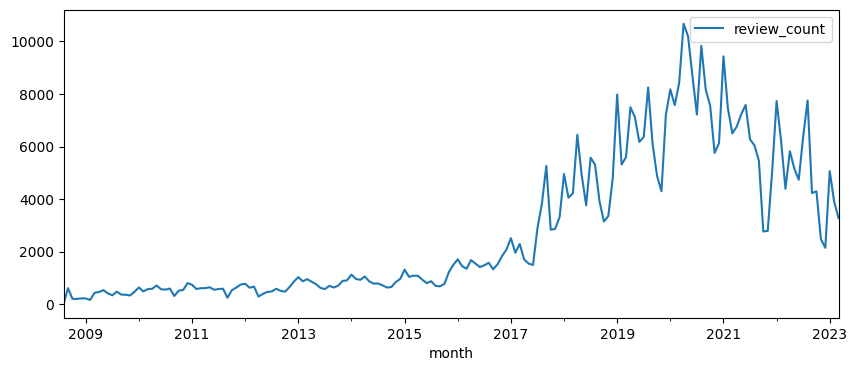

In [43]:
monthly_volume.plot(x="month", y="review_count", figsize=(10,4))


In [44]:
trend_table_clean = trend_table[
    (trend_table["month"] >= "2017-01") &
    (trend_table["review_count"] >= 30)
].copy()


In [45]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols_to_scale = [
    "review_count",
    "avg_rating",
    "rec_rate",
    "avg_sentiment",
    "avg_review_length"
]

trend_table_clean[[c+"_norm" for c in cols_to_scale]] = scaler.fit_transform(
    trend_table_clean[cols_to_scale]
)


In [46]:
df_ts = trend_table_clean.copy()


In [47]:
def growth_rate(group):
    group = group.sort_values("month")
    start = group.iloc[0]["review_count"]
    end = group.iloc[-1]["review_count"]
    return (end - start) / max(start, 1)

growth_df = (
    df_ts.groupby("tertiary_category")
         .apply(growth_rate)
         .reset_index(name="growth_rate")
)


C:\Users\mayas\AppData\Local\Temp\ipykernel_21832\3078405986.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(growth_rate)


In [48]:
metrics_df = (
    df_ts.groupby("tertiary_category")
    .agg(
        volume=("review_count", "mean"),
        rating=("avg_rating", "mean"),
        sentiment=("avg_sentiment", "mean"),
        engagement=("avg_review_length", "mean"),
    )
    .reset_index()
)


In [49]:
trend_score_df = metrics_df.merge(
    growth_df, on="tertiary_category", how="left"
)


In [50]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols = ["volume", "growth_rate", "rating", "sentiment", "engagement"]

trend_score_df[[c + "_norm" for c in cols]] = scaler.fit_transform(
    trend_score_df[cols]
)


In [51]:
trend_score_df["trend_score"] = (
    0.30 * trend_score_df["growth_rate_norm"] +
    0.25 * trend_score_df["volume_norm"] +
    0.20 * trend_score_df["sentiment_norm"] +
    0.15 * trend_score_df["rating_norm"] +
    0.10 * trend_score_df["engagement_norm"]
)


In [52]:
trend_score_df = trend_score_df.sort_values(
    "trend_score", ascending=False
)

trend_score_df.head(10)


,tertiary_category,volume,rating,sentiment,engagement,growth_rate,volume_norm,growth_rate_norm,rating_norm,sentiment_norm,engagement_norm,trend_score
15,Moisturizers,1473.613333,4.278143,0.684239,320.626933,-0.091623,1.000000,0.066045,0.559237,1.000000,0.656546,0.619354
7,Face Serums,952.880000,4.248425,0.632931,328.565590,4.120482,0.630314,0.452040,0.512368,0.730490,0.699820,0.586126
8,Face Sunscreen,282.873016,4.090558,0.606601,302.198972,10.100000,0.154653,1.000000,0.263390,0.592182,0.556096,0.552218
2,Exfoliators,206.364865,4.420538,0.662720,305.701109,3.390244,0.100338,0.385121,0.783812,0.886963,0.575186,0.493104
9,Face Wash & Cleansers,718.013333,4.213413,0.640908,293.769031,0.590571,0.463574,0.128561,0.457148,0.772392,0.510145,0.428527
13,Makeup Removers,108.676056,4.557615,0.648851,278.295837,0.193548,0.030985,0.092178,1.000000,0.814115,0.425801,0.390803
16,Night Creams,65.031250,4.289762,0.616015,344.468702,1.083333,0.000000,0.173717,0.577562,0.641632,0.786507,0.345727
5,Face Masks,378.920000,4.217077,0.632084,322.589745,-0.812325,0.222840,0.000000,0.462927,0.726040,0.667246,0.337082
3,Eye Creams & Treatments,307.264706,4.048737,0.616083,299.811489,1.489796,0.171970,0.210965,0.197434,0.641988,0.543082,0.318603
11,Facial Peels,205.875000,4.456850,0.585620,317.013687,-0.580645,0.099990,0.021231,0.841081,0.481975,0.636851,0.317609


In [53]:
top_categories = trend_score_df.head(5)[
    "tertiary_category"
].tolist()

top_categories


['Moisturizers',
 'Face Serums',
 'Face Sunscreen',
 'Exfoliators',
 'Face Wash & Cleansers']

In [54]:
keyword_map = {
    "Moisturizers": [
        "face moisturizer", "hydrating cream", "barrier repair cream"
    ],
    "Face Serums": [
        "face serum", "vitamin c serum", "niacinamide serum", "retinol serum"
    ],
    "Face Sunscreen": [
        "face sunscreen", "spf 50 sunscreen", "mineral sunscreen face"
    ],
    "Exfoliators": [
        "chemical exfoliant", "AHA BHA exfoliant", "salicylic acid exfoliant"
    ],
    "Face Wash & Cleansers": [
        "face cleanser", "gentle cleanser", "oil cleanser"
    ],
}


In [55]:
from pytrends.request import TrendReq
import pandas as pd
import time

pytrends = TrendReq(hl="en-US", tz=0)

def fetch_interest(keyword, timeframe="2019-01-01 2025-12-31"):
    pytrends.build_payload([keyword], timeframe=timeframe, geo="")
    df = pytrends.interest_over_time()
    if df.empty:
        return None
    df = df.reset_index()[["date", keyword]]
    df = df.rename(columns={keyword: "interest"})
    df["keyword"] = keyword
    return df

rows = []
for cat, kws in keyword_map.items():
    for kw in kws:
        out = fetch_interest(kw)
        if out is not None:
            out["category"] = cat
            rows.append(out)
        time.sleep(1)  # כדי לא לחטוף rate-limit

gt = pd.concat(rows, ignore_index=True)
gt.head()


,date,interest,keyword,category
0,2019-01-01,39,face moisturizer,Moisturizers
1,2019-02-01,38,face moisturizer,Moisturizers
2,2019-03-01,38,face moisturizer,Moisturizers
3,2019-04-01,34,face moisturizer,Moisturizers
4,2019-05-01,33,face moisturizer,Moisturizers


In [56]:
gt["month"] = gt["date"].dt.to_period("M")

gt_monthly = (
    gt.groupby(["category", "month"])["interest"]
      .mean()
      .reset_index(name="google_interest")
)

gt_monthly.head()


,category,month,google_interest
0,Exfoliators,2019-01,14.333333
1,Exfoliators,2019-02,13.666667
2,Exfoliators,2019-03,13.000000
3,Exfoliators,2019-04,15.666667
4,Exfoliators,2019-05,20.333333


In [57]:
import numpy as np

def slope(group):
    group = group.sort_values("month")
    y = group["google_interest"].values
    x = np.arange(len(y))
    if len(y) < 6:
        return np.nan
    m = np.polyfit(x, y, 1)[0]
    return m

google_slope = (
    gt_monthly.groupby("category")
              .apply(slope)
              .reset_index(name="google_trend_slope")
              .sort_values("google_trend_slope", ascending=False)
)

google_slope


C:\Users\mayas\AppData\Local\Temp\ipykernel_21832\318251664.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(slope)


,category,google_trend_slope
1,Face Serums,0.774286
3,Face Wash & Cleansers,0.553245
4,Moisturizers,0.521123
2,Face Sunscreen,0.517306
0,Exfoliators,0.459306


In [58]:
ts = trend_score_df.rename(columns={"tertiary_category": "category"}).copy()

final = ts.merge(google_slope, on="category", how="left")

final.sort_values("trend_score", ascending=False)[
    ["category", "trend_score", "google_trend_slope", "growth_rate", "volume", "rating", "sentiment"]
].head(10)


,category,trend_score,google_trend_slope,growth_rate,volume,rating,sentiment
0,Moisturizers,0.619354,0.521123,-0.091623,1473.613333,4.278143,0.684239
1,Face Serums,0.586126,0.774286,4.120482,952.880000,4.248425,0.632931
2,Face Sunscreen,0.552218,0.517306,10.100000,282.873016,4.090558,0.606601
3,Exfoliators,0.493104,0.459306,3.390244,206.364865,4.420538,0.662720
4,Face Wash & Cleansers,0.428527,0.553245,0.590571,718.013333,4.213413,0.640908
5,Makeup Removers,0.390803,NaN,0.193548,108.676056,4.557615,0.648851
6,Night Creams,0.345727,NaN,1.083333,65.031250,4.289762,0.616015
7,Face Masks,0.337082,NaN,-0.812325,378.920000,4.217077,0.632084
8,Eye Creams & Treatments,0.318603,NaN,1.489796,307.264706,4.048737,0.616083
9,Facial Peels,0.317609,NaN,-0.580645,205.875000,4.456850,0.585620


In [59]:
google_summary = (
    gt_monthly
    .groupby("category")
    .agg(
        google_level=("google_interest", "mean"),
        google_growth=("google_interest", lambda x: np.polyfit(range(len(x)), x, 1)[0])
    )
    .reset_index()
)

google_summary


,category,google_level,google_growth
0,Exfoliators,40.297619,0.459306
1,Face Serums,44.526786,0.774286
2,Face Sunscreen,32.916667,0.517306
3,Face Wash & Cleansers,43.976190,0.553245
4,Moisturizers,38.460317,0.521123


In [60]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

google_summary[["google_level_norm", "google_growth_norm"]] = scaler.fit_transform(
    google_summary[["google_level", "google_growth"]]
)


In [61]:
google_summary["google_score"] = (
    0.6 * google_summary["google_growth_norm"] +
    0.4 * google_summary["google_level_norm"]
)

google_summary.sort_values("google_score", ascending=False)


,category,google_level,google_growth,google_level_norm,google_growth_norm,google_score
1,Face Serums,44.526786,0.774286,1.000000,1.000000,1.000000
3,Face Wash & Cleansers,43.976190,0.553245,0.952576,0.298237,0.559973
4,Moisturizers,38.460317,0.521123,0.477484,0.196257,0.308748
0,Exfoliators,40.297619,0.459306,0.635734,0.000000,0.254294
2,Face Sunscreen,32.916667,0.517306,0.000000,0.184139,0.110483


In [62]:
final_df = final.merge(
    google_summary[["category", "google_score"]],
    on="category",
    how="left"
)


In [63]:
final_df["trend_2026_score"] = (
    0.65 * final_df["trend_score"] +   # דאטה אמיתי
    0.35 * final_df["google_score"]     # סיגנל חיצוני
)

final_df = final_df.sort_values("trend_2026_score", ascending=False)

final_df[[
    "category",
    "trend_2026_score",
    "trend_score",
    "google_score",
    "growth_rate",
    "volume",
    "rating",
    "sentiment"
]].head(10)


,category,trend_2026_score,trend_score,google_score,growth_rate,volume,rating,sentiment
1,Face Serums,0.730982,0.586126,1.000000,4.120482,952.880000,4.248425,0.632931
0,Moisturizers,0.510642,0.619354,0.308748,-0.091623,1473.613333,4.278143,0.684239
4,Face Wash & Cleansers,0.474533,0.428527,0.559973,0.590571,718.013333,4.213413,0.640908
3,Exfoliators,0.409520,0.493104,0.254294,3.390244,206.364865,4.420538,0.662720
2,Face Sunscreen,0.397611,0.552218,0.110483,10.100000,282.873016,4.090558,0.606601
5,Makeup Removers,NaN,0.390803,NaN,0.193548,108.676056,4.557615,0.648851
6,Night Creams,NaN,0.345727,NaN,1.083333,65.031250,4.289762,0.616015
7,Face Masks,NaN,0.337082,NaN,-0.812325,378.920000,4.217077,0.632084
8,Eye Creams & Treatments,NaN,0.318603,NaN,1.489796,307.264706,4.048737,0.616083
9,Facial Peels,NaN,0.317609,NaN,-0.580645,205.875000,4.456850,0.585620


In [64]:
import re
import time
import requests
import pandas as pd
from bs4 import BeautifulSoup
from urllib.parse import urlparse

URLS = [
    "https://www.allure.com/story/skin-care-trends-2025",
    "https://www.vogue.com/article/best-beauty-products-of-2024",
    "https://meiyume.com/global-skincare-trends-2025-2026/",
]

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120 Safari/537.36"
}

def fetch_html(url: str, timeout: int = 25) -> str:
    r = requests.get(url, headers=HEADERS, timeout=timeout)
    r.raise_for_status()
    return r.text

def clean_text(s: str) -> str:
    s = re.sub(r"\s+", " ", s).strip()
    return s

def extract_article_text(html: str):
    soup = BeautifulSoup(html, "lxml")

    # remove junk
    for tag in soup(["script", "style", "noscript", "svg"]):
        tag.decompose()

    title = soup.title.get_text(strip=True) if soup.title else ""

    # Try to focus on <article>, fallback to body
    container = soup.find("article") or soup.body or soup

    # Headings
    headings = []
    for h in container.find_all(["h1", "h2", "h3"]):
        t = clean_text(h.get_text(" ", strip=True))
        if t and len(t) >= 3:
            headings.append(t)

    # Paragraphs
    paragraphs = []
    for p in container.find_all("p"):
        t = clean_text(p.get_text(" ", strip=True))
        # filter obvious nav / cookie / subscribe lines
        if not t or len(t) < 40:
            continue
        if any(x in t.lower() for x in ["subscribe", "sign up", "cookie", "privacy", "newsletter"]):
            continue
        paragraphs.append(t)

    # keep not too long to be readable
    text = "\n".join(paragraphs[:80])

    return title, headings, text

rows = []
for url in URLS:
    try:
        html = fetch_html(url)
        title, headings, text = extract_article_text(html)
        rows.append({
            "url": url,
            "domain": urlparse(url).netloc,
            "title": title,
            "headings": headings,
            "text": text,
            "status": "ok",
        })
    except Exception as e:
        rows.append({
            "url": url,
            "domain": urlparse(url).netloc,
            "title": "",
            "headings": [],
            "text": "",
            "status": f"error: {type(e).__name__}: {e}",
        })
    time.sleep(1)  # עדינות

scraped = pd.DataFrame(rows)
scraped[["domain","status","title"]]


,domain,status,title
0,www.allure.com,ok,The Biggest Skin-Care Trends of 2025 Will Leve...
1,www.vogue.com,ok,"58 Best Beauty Products of 2025, According to ..."
2,meiyume.com,ok,Global Skincare Trends 2025/26: Shaping the Fu...


In [65]:
scraped.to_csv("../data/processed/editorial_scrape_raw.csv", index=False)


In [66]:
from collections import Counter

def tokenize(text: str):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s\-]", " ", text)
    tokens = [t for t in text.split() if len(t) >= 3]
    return tokens

all_tokens = []
for t in scraped["text"].fillna(""):
    all_tokens.extend(tokenize(t))

stop = set([
    "with","that","this","from","your","have","will","more","best","products","skin","skincare",
    "2024","2025","2026","into","also","about","over","their","they","them","than","when","what",
    "youre","it’s","its","our","and","the","for","are","was","were","but","not","too","can"
])

filtered = [w for w in all_tokens if w not in stop and not w.isdigit()]
top_words = Counter(filtered).most_common(40)
top_words[:20]


[('you', 44),
 ('like', 33),
 ('beauty', 33),
 ('body', 27),
 ('has', 26),
 ('says', 23),
 ('which', 21),
 ('one', 21),
 ('been', 20),
 ('hair', 19),
 ('all', 19),
 ('ingredients', 18),
 ('face', 17),
 ('love', 17),
 ('skin-care', 16),
 ('she', 16),
 ('use', 16),
 ('don', 16),
 ('product', 15),
 ('year', 15)]

In [67]:
category_terms = {
    "Face Serums": ["serum", "niacinamide", "retinol", "vitamin", "peptides", "hyaluronic"],
    "Moisturizers": ["moisturizer", "cream", "barrier", "ceramides", "hydrating"],
    "Face Sunscreen": ["sunscreen", "spf", "mineral", "uv", "zinc"],
    "Exfoliators": ["exfoliat", "aha", "bha", "salicylic", "glycolic", "lactic"],
    "Face Wash & Cleansers": ["cleanser", "face-wash", "wash", "oil-cleanser", "micellar"],
}

def count_category_mentions(text: str):
    text = text.lower()
    scores = {}
    for cat, terms in category_terms.items():
        c = 0
        for term in terms:
            if term.endswith("exfoliat"):
                continue
        # simple contains
        for term in terms:
            c += text.count(term)
        scores[cat] = c
    return scores

scraped_cats = []
for i, row in scraped.iterrows():
    scores = count_category_mentions(row["text"] or "")
    scores["url"] = row["url"]
    scraped_cats.append(scores)

scraped_cat_df = pd.DataFrame(scraped_cats)
scraped_cat_df


,Face Serums,Moisturizers,Face Sunscreen,Exfoliators,Face Wash & Cleansers,url
0,14,31,23,6,3,https://www.allure.com/story/skin-care-trends-...
1,22,20,7,2,4,https://www.vogue.com/article/best-beauty-prod...
2,0,0,0,0,0,https://meiyume.com/global-skincare-trends-202...


In [68]:
editorial_totals = scraped_cat_df.drop(columns=["url"]).sum().reset_index()
editorial_totals.columns = ["category", "editorial_mentions"]

# normalize to 0-1
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler()
editorial_totals["editorial_score"] = sc.fit_transform(editorial_totals[["editorial_mentions"]])

editorial_totals.sort_values("editorial_score", ascending=False)


,category,editorial_mentions,editorial_score
1,Moisturizers,51,1.000000
0,Face Serums,36,0.659091
2,Face Sunscreen,30,0.522727
3,Exfoliators,8,0.022727
4,Face Wash & Cleansers,7,0.000000


In [69]:
final_df2 = final_df.merge(
    editorial_totals[["category", "editorial_score"]],
    on="category",
    how="left"
)

final_df2["editorial_score"] = final_df2["editorial_score"].fillna(0)

final_df2["trend_2026_score_v2"] = (
    0.55 * final_df2["trend_score"] +
    0.30 * final_df2["google_score"] +
    0.15 * final_df2["editorial_score"]
)

final_df2.sort_values("trend_2026_score_v2", ascending=False)[
    ["category", "trend_2026_score_v2", "trend_score", "google_score", "editorial_score"]
].head(10)


,category,trend_2026_score_v2,trend_score,google_score,editorial_score
0,Face Serums,0.721233,0.586126,1.000000,0.659091
1,Moisturizers,0.583269,0.619354,0.308748,1.000000
4,Face Sunscreen,0.415274,0.552218,0.110483,0.522727
2,Face Wash & Cleansers,0.403682,0.428527,0.559973,0.000000
3,Exfoliators,0.350904,0.493104,0.254294,0.022727
5,Makeup Removers,NaN,0.390803,NaN,0.000000
6,Night Creams,NaN,0.345727,NaN,0.000000
7,Face Masks,NaN,0.337082,NaN,0.000000
8,Eye Creams & Treatments,NaN,0.318603,NaN,0.000000
9,Facial Peels,NaN,0.317609,NaN,0.000000


In [70]:
MAKEUP_URLS = [
    "https://www.allure.com/story/winter-makeup-trends-2025",
    "https://www.cosmopolitan.com/style-beauty/beauty/a69822086/makeup-trends-that-will-be-in-for-2026/",
]


In [71]:
rows = []
for url in MAKEUP_URLS:
    html = fetch_html(url)
    title, headings, text = extract_article_text(html)
    rows.append({
        "url": url,
        "domain": urlparse(url).netloc,
        "title": title,
        "headings": headings,
        "text": text,
        "chapter": "makeup_editorial"
    })

makeup_scraped = pd.DataFrame(rows)
makeup_scraped[["domain","title"]]


,domain,title
0,www.allure.com,Winter’s Biggest Makeup Trends Are High-Impact...
1,www.cosmopolitan.com,The Biggest Makeup Trends of 2026


In [72]:
import os
os.makedirs("data/processed", exist_ok=True)
makeup_scraped.to_csv("data/processed/makeup_editorial_scrape_raw.csv", index=False)


In [73]:
makeup_terms = {
    "Lips": ["lip", "lipstick", "gloss", "lip liner", "stain"],
    "Blush/Cheeks": ["blush", "cheek", "bronzer", "contour"],
    "Eyes": ["eyeliner", "mascara", "eyeshadow", "brow", "brows"],
    "Base": ["foundation", "concealer", "powder", "primer", "skin tint"],
    "Finish/Look": ["dewy", "matte", "glowy", "natural", "soft glam"],
}

def mention_counts(text: str, mapping: dict):
    t = (text or "").lower()
    out = {}
    for theme, terms in mapping.items():
        out[theme] = sum(t.count(term) for term in terms)
    return out

makeup_mentions = []
for _, r in makeup_scraped.iterrows():
    c = mention_counts(r["text"], makeup_terms)
    c["url"] = r["url"]
    makeup_mentions.append(c)

makeup_editorial_df = pd.DataFrame(makeup_mentions)
makeup_editorial_df


,Lips,Blush/Cheeks,Eyes,Base,Finish/Look,url
0,24,12,10,7,7,https://www.allure.com/story/winter-makeup-tre...
1,25,6,9,8,8,https://www.cosmopolitan.com/style-beauty/beau...


In [74]:
from sklearn.preprocessing import MinMaxScaler

editorial_theme = makeup_editorial_df.drop(columns=["url"]).sum().reset_index()
editorial_theme.columns = ["theme", "mentions"]

sc = MinMaxScaler()
editorial_theme["editorial_score"] = sc.fit_transform(editorial_theme[["mentions"]])

editorial_theme.sort_values("editorial_score", ascending=False)


,theme,mentions,editorial_score
0,Lips,49,1.000000
2,Eyes,19,0.117647
1,Blush/Cheeks,18,0.088235
3,Base,15,0.000000
4,Finish/Look,15,0.000000


In [75]:
lux_products["category"].value_counts().head(30)


category
Face Primer               243
Blush                     190
Setting Spray & Powder    188
Foundation                155
Concealer                 122
Bronzer                   119
Highlighter               108
Contouring                 62
Color Correcting           45
Makeup Remover             45
Tinted Moisturizer         39
BB & CC Creams             35
Name: count, dtype: int64

In [76]:
import re

makeup_keywords = [
    "lip", "lipstick", "gloss", "liner", "stain",
    "mascara", "eyeshadow", "eyeliner", "brow",
    "foundation", "concealer", "blush", "bronzer",
    "primer", "powder", "bb", "cc",
    "contour", "contouring", "highlighter",
    "color correcting", "corrector", "setting spray"
]

lux_products["category_l"] = (
    lux_products["category"]
    .astype("string")          # שומר NaN כ-<NA> ולא float
    .fillna("")                # הופך NaN למחרוזת ריקה
    .str.lower()
)

pattern = re.compile(r"\b(" + "|".join(re.escape(k) for k in makeup_keywords) + r")\b")

mask = lux_products["category_l"].str.contains(pattern, regex=True, na=False)

makeup_cats = lux_products[mask]["category"].value_counts()
makeup_cats.head(20)


C:\Users\mayas\AppData\Local\Temp\ipykernel_21832\62997524.py:21: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = lux_products["category_l"].str.contains(pattern, regex=True, na=False)


category
Face Primer               243
Blush                     190
Setting Spray & Powder    188
Foundation                155
Concealer                 122
Bronzer                   119
Highlighter               108
Contouring                 62
Color Correcting           45
BB & CC Creams             35
Name: count, dtype: int64

In [77]:
lux_makeup = lux_products[
    lux_products["category_l"].apply(lambda x: any(k in x for k in makeup_keywords))
].copy()

lux_makeup_summary = (
    lux_makeup.groupby("category")
    .agg(
        lux_volume=("num_reviews", "mean"),
        lux_rating=("average_rating", "mean"),
        lux_price=("price", "mean")
    )
    .reset_index()
)

# normalize + score
sc = MinMaxScaler()
lux_makeup_summary[["lux_volume_norm","lux_rating_norm"]] = sc.fit_transform(
    lux_makeup_summary[["lux_volume","lux_rating"]]
)

lux_makeup_summary["lux_score"] = 0.65*lux_makeup_summary["lux_volume_norm"] + 0.35*lux_makeup_summary["lux_rating_norm"]
lux_makeup_summary.sort_values("lux_score", ascending=False).head(15)


,category,lux_volume,lux_rating,lux_price,lux_volume_norm,lux_rating_norm,lux_score
3,Color Correcting,2668.577778,4.208444,24.950000,0.939118,0.184423,0.674975
0,BB & CC Creams,2817.857143,4.137429,29.526571,1.000000,0.000000,0.650000
5,Contouring,1982.209677,4.257419,25.562581,0.659191,0.311607,0.537536
7,Foundation,1807.535484,4.169613,34.063161,0.587952,0.083580,0.411422
2,Bronzer,678.210084,4.450588,24.551849,0.127369,0.813251,0.367428
8,Highlighter,365.907407,4.522500,30.734074,0.000000,1.000000,0.350000
4,Concealer,1187.254098,4.248525,23.941803,0.334977,0.288508,0.318713
1,Blush,416.057895,4.407211,22.737684,0.020453,0.700602,0.258505
9,Setting Spray & Powder,871.090426,4.244362,24.432872,0.206033,0.277697,0.231115
6,Face Primer,724.462810,4.190658,27.161646,0.146233,0.138234,0.143433


In [78]:
makeup_keyword_map = {
    "Lips": ["lip gloss", "lip stain", "lip liner"],
    "Blush/Cheeks": ["cream blush", "liquid blush", "bronzer stick"],
    "Eyes": ["brown mascara", "graphic eyeliner", "glitter eyeshadow"],
    "Base": ["skin tint", "serum foundation", "blurring primer"],
}


In [79]:
theme_map = {
    "lip": "Lips",
    "blush": "Blush/Cheeks",
    "bronzer": "Blush/Cheeks",
    "mascara": "Eyes",
    "eyeliner": "Eyes",
    "eyeshadow": "Eyes",
    "brow": "Eyes",
    "foundation": "Base",
    "concealer": "Base",
    "primer": "Base",
    "powder": "Base",
}


In [80]:
def map_theme(cat):
    c = str(cat).lower()
    for k, t in theme_map.items():
        if k in c:
            return t
    return "Other"

lux_makeup_summary["theme"] = lux_makeup_summary["category"].apply(map_theme)
lux_theme_score = lux_makeup_summary.groupby("theme")["lux_score"].mean().reset_index(name="lux_score_theme")
lux_theme_score


,theme,lux_score_theme
0,Base,0.276171
1,Blush/Cheeks,0.312967
2,Other,0.553128


In [81]:
import os, time, random
import numpy as np
import pandas as pd
from pytrends.request import TrendReq
from pytrends.exceptions import TooManyRequestsError
from sklearn.preprocessing import MinMaxScaler

# ---- 1) הגדרות ----
TIMEFRAME = "2021-01-01 2025-12-31"   # קצר יותר = פחות חסימות. אפשר להרחיב אחר כך.
GEO = ""                              # "" = עולמי. אפשר "US" אם את רוצה
HL = "en-US"
TZ = 0

# make sure you already have this dict from earlier:
# makeup_keyword_map = { "Lips": [...], "Eyes": [...], ... }

# ---- 2) pytrends init ----
pytrends = TrendReq(hl=HL, tz=TZ)

# ---- 3) cache folder ----
os.makedirs("data/processed/gt_cache_makeup", exist_ok=True)

def chunk(lst, n=5):
    """Google Trends allows up to 5 keywords per request"""
    for i in range(0, len(lst), n):
        yield lst[i:i+n]

def fetch_group(keywords, timeframe=TIMEFRAME, geo=GEO):
    """
    Fetch interest_over_time for up to 5 keywords in one request.
    Includes caching + exponential backoff for 429.
    Returns df with columns: date + each keyword
    """
    key = "__".join([k.replace(" ", "_") for k in keywords])
    cache_path = f"data/processed/gt_cache_makeup/{key}.csv"

    # cache hit
    if os.path.exists(cache_path):
        return pd.read_csv(cache_path, parse_dates=["date"])

    max_tries = 6
    base_sleep = 4

    for attempt in range(max_tries):
        try:
            pytrends.build_payload(keywords, timeframe=timeframe, geo=geo)
            df = pytrends.interest_over_time()
            if df is None or df.empty:
                return None

            df = df.reset_index()
            keep_cols = ["date"] + keywords
            df = df[keep_cols]

            df.to_csv(cache_path, index=False)
            return df

        except TooManyRequestsError:
            sleep_s = base_sleep * (2 ** attempt) + random.uniform(0, 2)
            print(f"429 hit. Sleeping {sleep_s:.1f}s (attempt {attempt+1}/{max_tries})...")
            time.sleep(sleep_s)

    raise RuntimeError("Still getting 429 after retries. Try again later or reduce keywords/timeframe.")

# ---- 4) Download GT data (theme -> keywords) ----
all_rows = []

for theme, kws in makeup_keyword_map.items():
    # remove duplicates just in case
    kws = list(dict.fromkeys(kws))

    for kws5 in chunk(kws, 5):
        df_wide = fetch_group(kws5)
        if df_wide is None:
            continue

        # wide -> long: date | keyword | interest
        df_long = df_wide.melt(id_vars=["date"], var_name="keyword", value_name="interest")
        df_long["theme"] = theme
        all_rows.append(df_long)

        time.sleep(1)  # gentle

    time.sleep(3)      # pause between themes (important!)

makeup_gt = pd.concat(all_rows, ignore_index=True)

# ---- 5) Monthly aggregation ----
makeup_gt["month"] = makeup_gt["date"].dt.to_period("M")

makeup_gt_monthly = (
    makeup_gt.groupby(["theme", "month"])["interest"]
    .mean()
    .reset_index(name="google_interest")
)

# ---- 6) Build google_score per theme ----
def slope_from_monthly(group):
    group = group.sort_values("month")
    y = group["google_interest"].values
    x = np.arange(len(y))
    if len(y) < 6:
        return np.nan
    return np.polyfit(x, y, 1)[0]

makeup_google_summary = (
    makeup_gt_monthly.groupby("theme")
    .agg(
        google_level=("google_interest", "mean"),
        google_growth=("google_interest", lambda _: np.nan)  # placeholder
    )
    .reset_index()
)

# compute slope separately (cleaner)
slopes = (
    makeup_gt_monthly.groupby("theme")
    .apply(slope_from_monthly)
    .reset_index(name="google_growth")
)

makeup_google_summary = makeup_google_summary.drop(columns=["google_growth"]).merge(slopes, on="theme", how="left")

# normalize + weighted score
scaler = MinMaxScaler()
makeup_google_summary[["google_level_norm", "google_growth_norm"]] = scaler.fit_transform(
    makeup_google_summary[["google_level", "google_growth"]]
)

makeup_google_summary["google_score"] = (
    0.6 * makeup_google_summary["google_growth_norm"] +
    0.4 * makeup_google_summary["google_level_norm"]
)

makeup_google_summary.sort_values("google_score", ascending=False)


C:\Users\mayas\AppData\Local\Temp\ipykernel_21832\831216222.py:118: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(slope_from_monthly)


,theme,google_level,google_growth,google_level_norm,google_growth_norm,google_score
1,Blush/Cheeks,37.237705,0.656298,1.000000,1.000000,1.000000
3,Lips,32.526230,0.329120,0.744480,0.308822,0.483085
0,Base,18.798907,0.472609,0.000000,0.611948,0.367169
2,Eyes,25.627322,0.182936,0.370329,0.000000,0.148131


In [82]:
makeup_google_summary


,theme,google_level,google_growth,google_level_norm,google_growth_norm,google_score
0,Base,18.798907,0.472609,0.000000,0.611948,0.367169
1,Blush/Cheeks,37.237705,0.656298,1.000000,1.000000,1.000000
2,Eyes,25.627322,0.182936,0.370329,0.000000,0.148131
3,Lips,32.526230,0.329120,0.744480,0.308822,0.483085


In [83]:
makeup_final = (lux_theme_score
    .merge(editorial_theme[["theme","editorial_score"]], on="theme", how="left")
    .merge(makeup_google_summary[["theme","google_score"]], on="theme", how="left")
)

makeup_final[["editorial_score","google_score"]] = makeup_final[["editorial_score","google_score"]].fillna(0)

makeup_final["makeup_2026_score"] = (
    0.55*makeup_final["lux_score_theme"] +
    0.30*makeup_final["google_score"] +
    0.15*makeup_final["editorial_score"]
)

makeup_final.sort_values("makeup_2026_score", ascending=False)


,theme,lux_score_theme,editorial_score,google_score,makeup_2026_score
1,Blush/Cheeks,0.312967,0.088235,1.000000,0.485367
2,Other,0.553128,0.000000,0.000000,0.304220
0,Base,0.276171,0.000000,0.367169,0.262044


In [84]:
final_df2.to_csv("data/processed/skincare_2026_forecast.csv", index=False)
makeup_final.to_csv("data/processed/makeup_2026_forecast.csv", index=False)

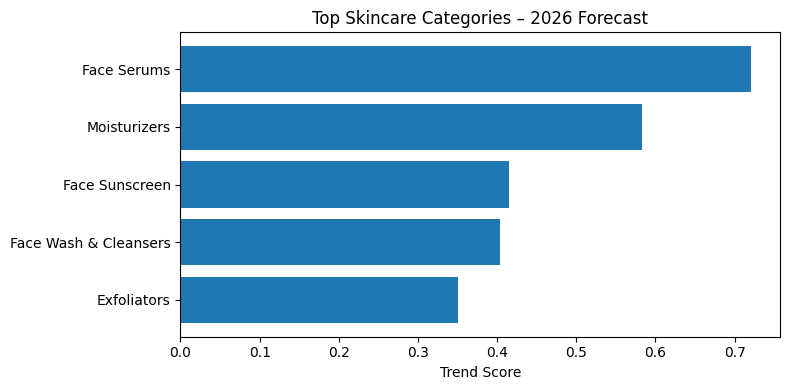

In [85]:
top_skin = (
    final_df2
    .sort_values("trend_2026_score_v2", ascending=False)
    .head(5)
)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.barh(top_skin["category"], top_skin["trend_2026_score_v2"])
plt.title("Top Skincare Categories – 2026 Forecast")
plt.xlabel("Trend Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

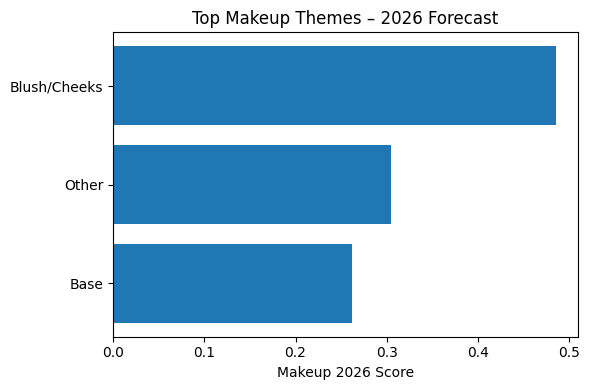

In [86]:
top_makeup = makeup_final.sort_values("makeup_2026_score", ascending=False)

plt.figure(figsize=(6,4))
plt.barh(top_makeup["theme"], top_makeup["makeup_2026_score"])
plt.title("Top Makeup Themes – 2026 Forecast")
plt.xlabel("Makeup 2026 Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [87]:
serums = df[df["tertiary_category"] == "Face Serums"].copy()

top_products = (
    serums["product_id"]
    .value_counts()
    .head(20)
    .index
)

serums = serums[serums["product_id"].isin(top_products)]

In [88]:
serums["month"] = serums["submission_time"].dt.to_period("M")

product_monthly = (
    serums.groupby(["product_id", "product_name_x", "month"])
    .size()
    .reset_index(name="review_count")
)

In [89]:
product_monthly = product_monthly.sort_values(["product_id", "month"])

for lag in [1, 2, 3]:
    product_monthly[f"lag_{lag}"] = (
        product_monthly
        .groupby("product_id")["review_count"]
        .shift(lag)
    )

product_monthly["rolling_3"] = (
    product_monthly
    .groupby("product_id")["review_count"]
    .rolling(3)
    .mean()
    .reset_index(level=0, drop=True)
)

product_monthly = product_monthly.dropna()

In [90]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

features = ["lag_1", "lag_2", "lag_3", "rolling_3"]
X = product_monthly[features]
y = product_monthly["review_count"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, shuffle=False, test_size=0.2
)

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [91]:
product_monthly["predicted_next"] = model.predict(X)

forecast_top = (
    product_monthly
    .groupby(["product_id", "product_name_x"])
    .tail(1)
    .sort_values("predicted_next", ascending=False)
    .head(5)
)

In [92]:
import numpy as np
import pandas as pd

def forecast_t_plus_6_for_product(hist_df, model, steps=6):
    """
    hist_df: DataFrame של מוצר אחד, ממויין לפי month, עם review_count
    מחזיר DataFrame עם month_forecast + yhat
    """
    hist_df = hist_df.sort_values("month").copy()
    last_month = hist_df["month"].max()

    # נשתמש ב-3 חודשים אחרונים כדי להתחיל
    y = hist_df["review_count"].tolist()
    if len(y) < 6:
        return None  # לא מספיק היסטוריה

    preds = []
    # מתחילים מהאחרון
    lag1 = y[-1]
    lag2 = y[-2]
    lag3 = y[-3]

    # rolling_3 על 3 האחרונים
    roll3 = np.mean([lag1, lag2, lag3])

    cur_month = last_month
    for _ in range(steps):
        X_next = pd.DataFrame([{
            "lag_1": lag1,
            "lag_2": lag2,
            "lag_3": lag3,
            "rolling_3": roll3
        }])

        yhat = float(model.predict(X_next)[0])

        # אופציונלי: לא לאפשר שלילי
        yhat = max(0.0, yhat)

        cur_month = cur_month + 1  # Period + 1 חודש
        preds.append({"month": cur_month, "yhat": yhat})

        # עדכון ל-lags: מזיזים
        lag3, lag2, lag1 = lag2, lag1, yhat
        roll3 = np.mean([lag1, lag2, lag3])

    return pd.DataFrame(preds)

In [93]:
def forecast_all_top_products(product_monthly, top_product_ids, model, steps=6):
    out = []
    for pid in top_product_ids:
        hist = product_monthly[product_monthly["product_id"] == pid].copy()
        name = hist["product_name_x"].iloc[0] if "product_name_x" in hist.columns else str(pid)

        fc = forecast_t_plus_6_for_product(hist, model, steps=steps)
        if fc is None:
            continue

        last_actual = float(hist.sort_values("month")["review_count"].iloc[-1])
        fc_sum = float(fc["yhat"].sum())  # “ביקוש מצטבר” ל-6 חודשים
        uplift_abs = fc_sum - (last_actual * steps)  # מול קו ישר של “כמו החודש האחרון”
        uplift_pct = (uplift_abs / (last_actual * steps + 1e-9)) * 100

        out.append({
            "product_id": pid,
            "product_name": name,
            "last_actual": last_actual,
            "forecast_6m_sum": fc_sum,
            "uplift_abs": uplift_abs,
            "uplift_pct": uplift_pct
        })

    return pd.DataFrame(out).sort_values("uplift_abs", ascending=False)

# לדוגמה: משתמשים באותם top_products שבחרת קודם
top_product_ids = list(top_products)  # אם top_products הוא Index
forecast_rank = forecast_all_top_products(product_monthly, top_product_ids, model, steps=6)

forecast_rank.head(10)

,product_id,product_name,last_actual,forecast_6m_sum,uplift_abs,uplift_pct
1,P309308,Good Genes All-In-One AHA Lactic Acid Treatment,51.0,469.650,163.650,53.480392
0,P427417,Niacinamide 10% + Zinc 1% Oil Control Serum,47.0,414.265,132.265,46.902482
6,P421235,Double Serum Firming & Smoothing Anti-Aging Co...,2.0,78.680,66.680,555.666667
2,P427419,Hyaluronic Acid 2% + B5 Hydrating Serum,54.0,388.340,64.340,19.858025
12,P427414,Natural Moisturizing Factors + HA,17.0,154.270,52.270,51.245098
14,P443845,Hyaluronic Acid Hydrating Serum,15.0,124.615,34.615,38.461111
16,P500633,Tea Elixir Niacinamide & Hyaluronic Acid Anti-...,1.0,21.020,15.020,250.333333
9,P461933,Advanced Night Repair Synchronized Multi-Recov...,3.0,29.810,11.810,65.611111
8,P461159,Estee Lauder Advanced Night Repair Synchronize...,3.0,29.810,11.810,65.611111
4,P392246,T.L.C. Framboos Glycolic Resurfacing Night Serum,5.0,39.085,9.085,30.283333


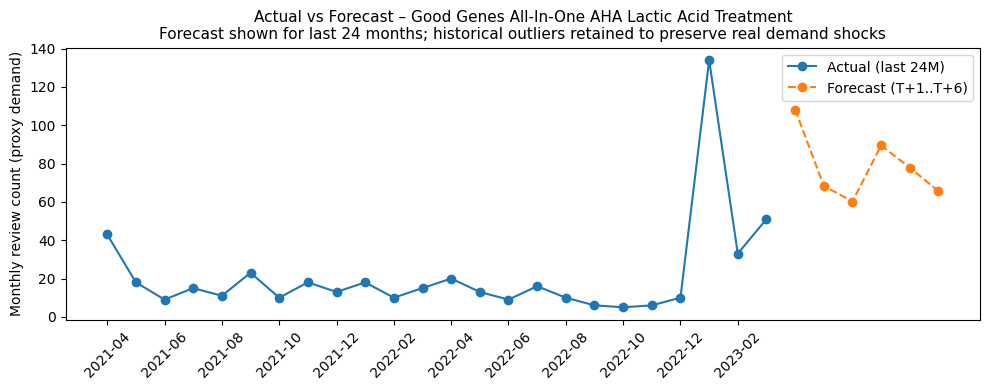

In [94]:
import matplotlib.pyplot as plt
import pandas as pd

# בחרי מוצר
pid = forecast_rank.iloc[0]["product_id"]
product_name = forecast_rank.iloc[0]["product_name"]

hist = (
    product_monthly[product_monthly["product_id"] == pid]
    .sort_values("month")
    .copy()
)

# רק 24 חודשים אחרונים
hist_tail = hist.tail(24).copy()

# תחזית 6 חודשים קדימה (נשענת על כל ההיסטוריה!)
fc = forecast_t_plus_6_for_product(hist, model, steps=6)

plt.figure(figsize=(10,4))
plt.plot(hist_tail["month"].astype(str), hist_tail["review_count"], marker="o", label="Actual (last 24M)")
plt.plot(fc["month"].astype(str), fc["yhat"], marker="o", linestyle="--", label="Forecast (T+1..T+6)")

# להוריד כיתובים צפופים: רק כל 2 תוויות
ticks = list(range(0, len(hist_tail), 2))
plt.xticks(ticks, hist_tail["month"].astype(str).iloc[ticks], rotation=45)

plt.title(
    f"Actual vs Forecast – {product_name}\n"
    "Forecast shown for last 24 months; historical outliers retained to preserve real demand shocks",
    fontsize=11
)
plt.ylabel("Monthly review count (proxy demand)")
plt.legend()
plt.tight_layout()
plt.show()


In [95]:
pm = product_monthly.sort_values(["product_id", "month"]).copy()

In [96]:
pm["baseline_pred"] = pm["lag_1"]
pm["model_pred"] = model.predict(pm[features])   # features = ["lag_1","lag_2","lag_3","rolling_3"]

In [97]:
from sklearn.metrics import mean_absolute_error

pm = pm.dropna(subset=["baseline_pred", "model_pred", "review_count"]).copy()

split_idx = int(len(pm) * 0.8)
test = pm.iloc[split_idx:].copy()

mae_baseline = mean_absolute_error(test["review_count"], test["baseline_pred"])
mae_model = mean_absolute_error(test["review_count"], test["model_pred"])

mae_baseline, mae_model

(14.648760330578513, 7.144855371900828)

In [98]:
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    denom = np.where(y_true == 0, 1, y_true)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100

mape_baseline = mape(test["review_count"], test["baseline_pred"])
mape_model = mape(test["review_count"], test["model_pred"])

mape_baseline, mape_model

(np.float64(56.33702010022065), np.float64(51.9776365801149))

In [99]:
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    denom = np.where(y_true == 0, 1, y_true)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100

mape_baseline = mape(test["review_count"], test["baseline_pred"])
mape_model = mape(test["review_count"], test["model_pred"])

mape_baseline, mape_model

(np.float64(56.33702010022065), np.float64(51.9776365801149))

In [100]:
print(f"Baseline (naive) MAE: {mae_baseline:.2f}")
print(f"Model MAE:           {mae_model:.2f}")
print(f"Baseline MAPE:       {mape_baseline:.1f}%")
print(f"Model MAPE:          {mape_model:.1f}%")

Baseline (naive) MAE: 14.65
Model MAE:           7.14
Baseline MAPE:       56.3%
Model MAPE:          52.0%


In [101]:
import joblib, os

os.makedirs("models", exist_ok=True)
joblib.dump(model, "models/product_demand_rf.pkl")

['models/product_demand_rf.pkl']

In [102]:
os.makedirs("data/processed", exist_ok=True)

forecast_rank.to_csv(
    "data/processed/product_forecast_6m_rank.csv",
    index=False
)

In [103]:
import pandas as pd

metrics_df = pd.DataFrame({
    "metric": ["MAE", "MAPE"],
    "baseline": [mae_baseline, mape_baseline],
    "model": [mae_model, mape_model]
})

metrics_df.to_csv(
    "data/processed/model_evaluation_metrics.csv",
    index=False
)

In [104]:
product_monthly.to_csv("data/processed/product_monthly_table.csv", index=False)